## Plotting derivative

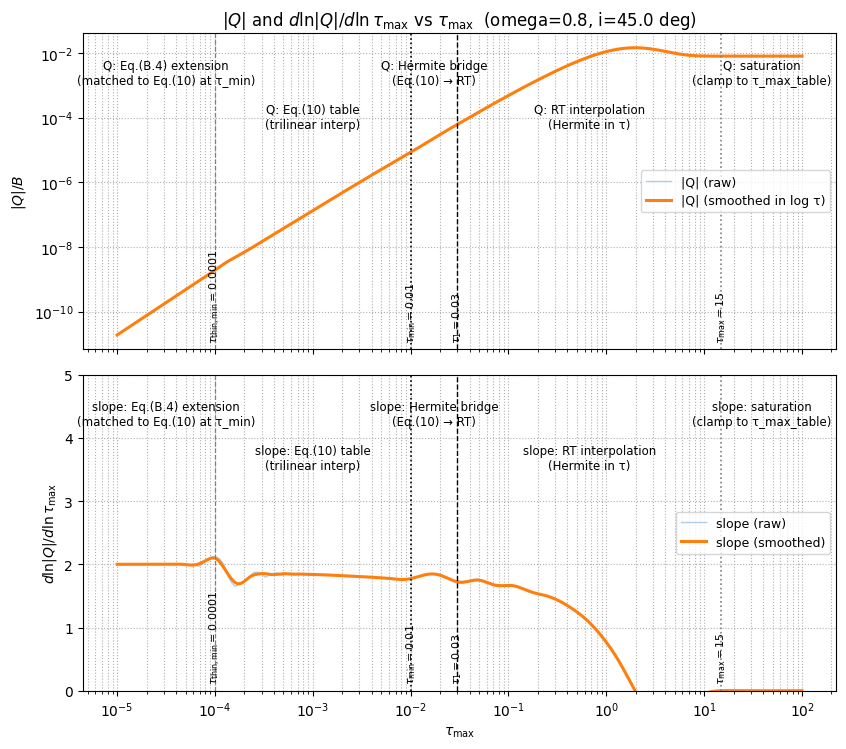

In [1]:
from emergentintensity import emergent_stokes, INTERP_TABLES, Q_THIN_TABLE, setup_tables

import numpy as np
import matplotlib.pyplot as plt

# =========================
# User parameters
# =========================
omega0 = 0.8
inc0   = 45.0
tau_vals = np.logspace(-5, 2, 700)  # 1e-5 ... 1e2

# Smoothing knobs (tune if needed)
SMOOTH_IN_LOGTAU = True
SAVGOL_WINDOW = 41   # must be odd; typical 21-81
SAVGOL_POLY   = 3    # 2-4 is typical

# =========================
# Ensure tables loaded
# =========================
if INTERP_TABLES is None:
    setup_tables()

tau_grid = INTERP_TABLES["tau_grid"]
tau_min_table = float(tau_grid[0])
tau_1         = float(tau_grid[1])
tau_max_table = float(tau_grid[-1])

has_eq10 = (Q_THIN_TABLE is not None)
if has_eq10:
    tau_min_thin = float(Q_THIN_TABLE["tau_grid"][0])   # usually ~1e-4
    tau_max_thin = float(Q_THIN_TABLE["tau_grid"][-1])  # usually ~ tau_min_table
else:
    tau_min_thin = None
    tau_max_thin = None

# =========================
# Compute Q(tau) (patched)
# =========================
Q_arr = np.empty_like(tau_vals, dtype=float)
for i, t in enumerate(tau_vals):
    I, Q = emergent_stokes(float(t), float(omega0), float(inc0))
    Q_arr[i] = float(Q)

# =========================
# Helper: smoothing on log(tau) grid
# =========================
def _moving_average(y, window):
    y = np.asarray(y, dtype=float)
    if window < 3:
        return y.copy()
    if window % 2 == 0:
        window += 1
    pad = window // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    ker = np.ones(window, dtype=float) / float(window)
    return np.convolve(ypad, ker, mode="valid")

def _savgol_or_ma(y, window, poly):
    y = np.asarray(y, dtype=float)
    if window % 2 == 0:
        window += 1
    window = int(np.clip(window, 5, len(y) - (len(y)+1) % 2))  # keep odd, <= len(y)
    if window >= len(y):
        window = len(y) - 1
        if window % 2 == 0:
            window -= 1
    if window < 5:
        return y.copy()

    try:
        from scipy.signal import savgol_filter
        poly = int(np.clip(poly, 1, window - 2))
        return savgol_filter(y, window_length=window, polyorder=poly, mode="interp")
    except Exception:
        # SciPy not available or savgol failed
        return _moving_average(y, window)

# =========================
# Prepare |Q| and its log-log slope
# =========================
# Use |Q| for log scaling; clip to avoid log(0)
Qabs = np.abs(Q_arr)
Qabs = np.clip(Qabs, 1e-300, None)

logtau = np.log(tau_vals)
logQ   = np.log(Qabs)

# Smooth in log(tau) domain (recommended)
if SMOOTH_IN_LOGTAU:
    logQ_smooth = _savgol_or_ma(logQ, SAVGOL_WINDOW, SAVGOL_POLY)
else:
    logQ_smooth = logQ.copy()

# Slope: d ln|Q| / d ln tau  (use smoothed logQ)
dlogQ_dlogtau = np.gradient(logQ_smooth, logtau)

# Optional: also smooth the slope a bit (often helps)
dlogQ_dlogtau_smooth = _savgol_or_ma(dlogQ_dlogtau, max(11, SAVGOL_WINDOW // 2 * 2 + 1), 2)

# For plotting |Q| smoothly: exp(logQ_smooth)
Qabs_smooth = np.exp(logQ_smooth)

# =========================
# Helper: regime boundaries + annotations (same as your logic)
# =========================
def _geom_mid(a, b):
    a = float(a); b = float(b)
    return 10.0 ** (0.5 * (np.log10(a) + np.log10(b)))

def _place_region_text(ax, x0, x1, text, yfrac=0.92, fontsize=9):
    xmid = _geom_mid(x0, x1)
    ax.text(
        xmid, yfrac, text,
        transform=ax.get_xaxis_transform(),
        ha="center", va="top", fontsize=fontsize
    )

def _vline(ax, x, label=None, **kw):
    ax.axvline(x, **kw)
    if label is not None:
        ax.text(
            x, 0.02, label,
            transform=ax.get_xaxis_transform(),
            ha="center", va="bottom", fontsize=8, rotation=90
        )

bounds = [float(tau_vals.min())]
if has_eq10:
    if (tau_min_thin is not None) and (tau_vals.min() < tau_min_thin < tau_vals.max()):
        bounds.append(float(tau_min_thin))
    bounds.append(float(tau_min_table))
else:
    bounds.append(float(tau_min_table))
bounds.append(float(tau_1))
bounds.append(float(tau_max_table))
bounds.append(float(tau_vals.max()))

bounds = sorted(set([float(np.clip(b, tau_vals.min(), tau_vals.max())) for b in bounds]))
if bounds[0] != float(tau_vals.min()):
    bounds = [float(tau_vals.min())] + bounds
if bounds[-1] != float(tau_vals.max()):
    bounds = bounds + [float(tau_vals.max())]

region_labels = []
for j in range(len(bounds) - 1):
    a, b = bounds[j], bounds[j+1]
    tm = _geom_mid(a, b)

    if tm < tau_min_table:
        if has_eq10:
            if (tau_min_thin is not None) and (tm < tau_min_thin):
                region_labels.append("Q: Eq.(B.4) extension\n(matched to Eq.(10) at τ_min)")
            else:
                region_labels.append("Q: Eq.(10) table\n(trilinear interp)")
        else:
            region_labels.append("Q: thin approx ∝ τ²\n(matched to RT at τ_min)")
    elif tau_min_table <= tm <= tau_1:
        if has_eq10:
            region_labels.append("Q: Hermite bridge\n(Eq.(10) → RT)")
        else:
            region_labels.append("Q: Hermite bridge\n(thin → RT)")
    elif tau_1 < tm <= tau_max_table:
        region_labels.append("Q: RT interpolation\n(Hermite in τ)")
    else:
        region_labels.append("Q: saturation\n(clamp to τ_max_table)")

# =========================
# Plot: |Q| (loglog) and slope (semilogx, linear y)
# =========================
fig, axes = plt.subplots(2, 1, figsize=(8.6, 7.6), sharex=True)
axQ, axS = axes

# |Q| panel
axQ.loglog(tau_vals, Qabs, lw=1.0, alpha=0.35, label="|Q| (raw)")
axQ.loglog(tau_vals, Qabs_smooth, lw=2.2, label="|Q| (smoothed in log τ)")
axQ.set_ylabel(r"$|Q|/B$")
axQ.set_title(
    fr"$|Q|$ and $d\ln|Q|/d\ln\tau_{{\rm max}}$ vs $\tau_{{\rm max}}$  (omega={omega0}, i={inc0} deg)"
)
axQ.grid(True, which="both", ls=":")
axQ.legend(loc="best", fontsize=9)

# slope panel (linear y, x log)
axS.semilogx(tau_vals, dlogQ_dlogtau, lw=1.0, alpha=0.35, label="slope (raw)")
axS.semilogx(tau_vals, dlogQ_dlogtau_smooth, lw=2.2, label="slope (smoothed)")
axS.set_ylabel(r"$d\ln|Q|/d\ln\tau_{{\rm max}}$")
axS.set_xlabel(r"$\tau_{\rm max}$")
axS.grid(True, which="both", ls=":")
axS.set_ylim(0.0, 5.0)
axS.legend(loc="best", fontsize=9)

# regime boundary lines
for ax in (axQ, axS):
    _vline(ax, tau_min_table, label=fr"$\tau_{{\min}}={tau_min_table:g}$", color="k", ls=":", lw=1.2)
    _vline(ax, tau_1,         label=fr"$\tau_1={tau_1:g}$",             color="k", ls="--", lw=1.0)
    _vline(ax, tau_max_table, label=fr"$\tau_{{\max}}={tau_max_table:g}$", color="gray", ls=":", lw=1.2)
    if has_eq10 and (tau_min_thin is not None) and (tau_vals.min() < tau_min_thin < tau_vals.max()):
        _vline(ax, tau_min_thin, label=fr"$\tau_{{\rm thin,min}}={tau_min_thin:g}$", color="gray", ls="--", lw=0.9)

# region texts (same labels on both panels)
for j in range(len(bounds) - 1):
    a, b = bounds[j], bounds[j+1]
    yfrac = 0.92 if (j % 2 == 0) else 0.78
    _place_region_text(axQ, a, b, region_labels[j], yfrac=yfrac, fontsize=8.5)
    _place_region_text(axS, a, b, region_labels[j].replace("Q:", "slope:"), yfrac=yfrac, fontsize=8.5)

plt.tight_layout()
plt.show()